# CIFAR-10 Classification

## 1.3 ResNet-18 Architecture + Data Augmentation

In [45]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns

In [46]:
import numpy as np
import random
import os

seed = 42
# Setting Python and NumPy seeds
random.seed(seed)
np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
    
# Setting PyTorch seeds (CPU and all GPUs)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
    
# Ensure deterministic behavior in cuDNN
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [47]:
TRAIN_MODEL = False
SAVE_MODEL = False

In [48]:
# Checking if CUDA is available and setting the device accordingly.
# If a GPU is available, it will be used for computations; otherwise, the code will fall back to the CPU.
# In this case, I am using an RTX 3060 GPU, which supports CUDA.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:
print(device)

cuda:0


## Preprocessing

In [ ]:
train_transform = transforms.Compose(
    [
        # Adding random cropping by increasing the padding to 4 so the size
        # of the image increases from 32x32 to 40x40, then randomly cropping
        # the image to 32x32 again
        transforms.RandomCrop(32, padding=4),
        # Horizontally flipping each image with 50% probability, meaning each image has
        # a 50% probability of being flipped horizontally
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        # Using the dataset mean and standard deviation instead of 0.5
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                (0.2023, 0.1994, 0.2010))
    ]
)

test_transform = transforms.Compose(
    [
        # Not applying augmentation to the test dataset because we want the test
        # data to remain clean and fair; we only want to introduce this to
        # the training dataset
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
            (0.2023, 0.1994, 0.2010))
    ]
)

batch_size = 64

trainset = torchvision.datasets.CIFAR10(root='../data', train=True,
                                        download=False, transform=train_transform)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

testset = torchvision.datasets.CIFAR10(root='../data', train=False,
                                        download=False, transform=test_transform)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

## ResNet-18 Architecture

![Cifar Res Net 18](resnet18_full_visual_flow_readable.png)

In [50]:
# Reusable convolution layer with a 3x3 kernel and same padding. I am going to use batch normalization
# after each use of this layer, so bias=False is important.
def conv3x3(in_channels, out_channels, stride=1):
    return nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=3,
        stride=stride,
        padding=1,
        bias=False
    )

# Reusable convolution layer with a 1x1 kernel. I am going to use batch normalization
# after each use of this layer, so bias=False is important.
def conv1x1(in_channels, out_channels, stride=1):
    return nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=1,
        stride=stride,
        bias=False
    )

In [51]:
# Constructing a BasicBlock. This network will be mainly for educational purposes,
# not generalization, as it will only focus on ResNet-18, so the Bottleneck block
# is unnecessary.

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        
        # ResNet 18 applies 2 convolution layers before adding the skip or shortcut connection to the
        # new function
        # This block has these 2 convolution layers with batch normalization and ReLU layers
        self.conv1 = conv3x3(in_channels=in_channels, out_channels=out_channels, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = conv3x3(in_channels=out_channels, out_channels=out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.downsample = downsample
    
    def forward(self, x):
        # Our identity is the original input image before the 2 convolution layers
        identity = x 
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # if there's a downsample block we apply it to the identity to increase the number of channels
        # or decrease the spatial size
        if self.downsample is not None:
            identity = self.downsample(x)
        
        # Image after the 2 convolution layers + the original image prior to the layers
        out = out + identity
        # we apply relu here to introduce non-linearity to the final output
        out = self.relu(out)
        
        return out

In [52]:
class ResNet(nn.Module):
    def __init__(self, num_classes=10): # num_classes is set to 10 because the CIFAR-10 dataset has only 10 labels for prediction
        super().__init__()
        
        # Here our architecture suggests that the first layer should output 64 features
        self.in_channels = 64
        
        # this is the stem convolution layer which we learn basic information about our
        # original image, then we output the same spatial dimension but 64 channels instead of 3
        # for our Basic Blocks
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
            )
        
        self.bn1 = nn.BatchNorm2d(64)
        
        # inplace=True makes PyTorch overwrite the original tensor instead of creating a new one
        # it saves a bit of memory that's why it's used here
        self.relu = nn.ReLU(inplace=True)
        
        # Our 4 stages or layers are the base blocks for ResNet-18
        # Here we make the image from the stem layer go through 4 layers with
        # a varying number of blocks; in this case, it is 2 for each to train different
        # parameters
        # 64 x 32 x 32 -> 64 x 32 x 32 -> 128 x 16 x 16 -> 256 x 8 x 8 -> 512 x 4 x 4
        self.layer1 = self.make_layer(out_channels=64, num_blocks=2, stride=1)
        self.layer2 = self.make_layer(out_channels=128, num_blocks=2, stride=2)
        self.layer3 = self.make_layer(out_channels=256, num_blocks=2, stride=2)
        self.layer4 = self.make_layer(out_channels=512, num_blocks=2, stride=2)
        
        # at the end of our cnn layers we make the image go through avg pooling layer to change
        # its spatial dimensions from 512 x 4 x 4 to 512 x 1 x 1
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        # Final fully connected layer to predict logits for each class
        self.fc1 = nn.Linear(512, num_classes)
    
    # function to create a new stage or layer for ResNet
    def make_layer(self, out_channels, num_blocks, stride):
        # No downsampling by default
        downsample = None
        
        # If stride is not 1, meaning the spatial dimensions have changed, or
        # if number of input channels is not equal to out channels meaning
        # the number of channels is not the same. For example, the skip connection from layer 1 had an output
        # of 64 channels and 32 x 32 spatial dimensions but we want to add it to an image with
        # 128 channels and 16 x 16 spatial dimensions this is not possible so we have to downsample
        # the skip connection to make it fit
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                # 1x1 convolutions are useful for changing channels and spatial dimensions because
                # it doesn't focus on neighboring pixels just how to change each pixel based on the
                # current channels
                conv1x1(self.in_channels, out_channels, stride),
                # we pass it through batch norm layer to normalize the outputs
                nn.BatchNorm2d(out_channels)
            )
        
        # Creating a layers list to store all blocks
        layers = []
        # this is the first block our main focus here is to change the input's channels and spatial
        # dimension and learn some features
        layers.append(BasicBlock(
            in_channels=self.in_channels,
            out_channels=out_channels,
            stride=stride,
            downsample=downsample
            ))
        
        # since the number of input channels are equal to the number of output channels by default
        # or by downsampling we set in_channels equal to out_channels to pass it along the layers
        self.in_channels = out_channels
        
        # for loop to pass the output of the first block through the rest of the blocks
        # here the spatial dimenstions and channels are the same because we already changed
        # it in the first block 
        
        # in this instance this for loop will run only once because we have num_blocks set to 2
        # in each layer
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(
                in_channels=self.in_channels,
                out_channels=out_channels
                ))
        
        # Since nn.Sequential expects multiple arguments, not a list, we unpack layers using
        # *layers to turn it into arguments [block1, block2] -> (block1, block2)
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # just the basic flow of the image through the neural network from the ResNet 18 Graph
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        
        return x

Cifar_10_ResNet = ResNet(num_classes=10)

Cifar_10_ResNet.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=Fals

In [53]:
# Using the Adam optimizer with a 0.001 learning rate and 0.0001 L2 weight decay
optimizer = optim.Adam(Cifar_10_ResNet.parameters(), lr=1e-3, weight_decay=1e-4)

criterion = nn.CrossEntropyLoss()

In [54]:
# Special thanks to Kiel Dang for the well-explained article: Deep Learning — Computer Vision (CV)
# using Transfer Learning (ResNet-18) in PyTorch — Skin Cancer Classification.

# This is the training cell I used as a reference to train my model. It monitors train and test
# accuracy and loss per epoch, which is great for monitoring and analysis later on.
if TRAIN_MODEL:
    # Train model
    train_loss=[]
    train_accuary=[]
    test_loss=[]
    test_accuary=[]

    num_epochs = 20   #(set number of epochs)
    start_time = time.time() #(for tracking time)
    # Start loop
    for epoch in range(num_epochs): #(loop for every epoch)
        print("Epoch {} running".format(epoch)) #(printing message)
        """ Training Phase """
        Cifar_10_ResNet.train()    #(training model)
        running_loss = 0.   #(set loss 0)
        running_corrects = 0 
        # load a batch data of images
        for i, (inputs, labels) in enumerate(trainloader):
            inputs = inputs.to(device)
            labels = labels.to(device) 
            # forward inputs and get output
            optimizer.zero_grad()
            outputs = Cifar_10_ResNet(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            # get loss value and update the network weights
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            running_corrects += torch.sum(preds == labels.data).item()
        epoch_loss = running_loss / len(trainset)
        epoch_acc = running_corrects / len(trainset) * 100.
        # Append result
        train_loss.append(epoch_loss)
        train_accuary.append(epoch_acc)
        # Print progress
        print('[Train #{}] Loss: {:.4f} Acc: {:.4f}% Time: {:.4f}s'.format(epoch+1, epoch_loss, epoch_acc, time.time() -start_time))
        """ Testing Phase """
        Cifar_10_ResNet.eval()
        with torch.no_grad():
            running_loss = 0.
            running_corrects = 0
            for inputs, labels in testloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = Cifar_10_ResNet(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                running_corrects += torch.sum(preds == labels.data).item()
            epoch_loss = running_loss / len(testset)
            epoch_acc = running_corrects / len(testset) * 100.
            # Append result
            test_loss.append(epoch_loss)
            test_accuary.append(epoch_acc)
            # Print progress
            print('[Test #{}] Loss: {:.4f} Acc: {:.4f}% Time: {:.4f}s'.format(epoch+1, epoch_loss, epoch_acc, time.time()- start_time))

In [ ]:
# Saving the model after training it so we can load it later without needing to train it again
if SAVE_MODEL:
    PATH = "../models/cifar_resnet_scratch.pth"
    torch.save(Cifar_10_ResNet, PATH)

In [ ]:
# Saving the training and test loss and accuracy in tables for later analysis and visualization
if SAVE_MODEL:
    train_loss_table = pd.DataFrame(train_loss, columns=["Loss"])
    train_loss_table["Epoch"] = train_loss_table.index + 1

    train_accuracy_table = pd.DataFrame(train_accuary, columns=["Accuracy"])
    train_accuracy_table["Epoch"] = train_accuracy_table.index + 1
    
    test_loss_table = pd.DataFrame(test_loss, columns=["Loss"])
    test_loss_table["Epoch"] = test_loss_table.index + 1
    
    test_accuracy_table = pd.DataFrame(test_accuary, columns=["Accuracy"])
    test_accuracy_table["Epoch"] = test_accuracy_table.index + 1
    
    train_loss_table.to_csv("../tables/ResNet_Scratch/training_loss.csv", index=False)
    train_accuracy_table.to_csv("../tables/ResNet_Scratch/training_accuracy.csv", index=False)
    
    test_loss_table.to_csv("../tables/ResNet_Scratch/test_loss.csv", index=False)
    test_accuracy_table.to_csv("../tables/ResNet_Scratch/test_accuracy.csv", index=False)

In [ ]:
# If SAVE_MODEL is False, we load our saved CSV files
if not SAVE_MODEL:
    train_loss_table = pd.read_csv("../tables/ResNet_Scratch/training_loss.csv")
    train_accuracy_table = pd.read_csv("../tables/ResNet_Scratch/training_accuracy.csv")
    test_loss_table = pd.read_csv("../tables/ResNet_Scratch/test_loss.csv")
    test_accuracy_table = pd.read_csv("../tables/ResNet_Scratch/test_accuracy.csv")

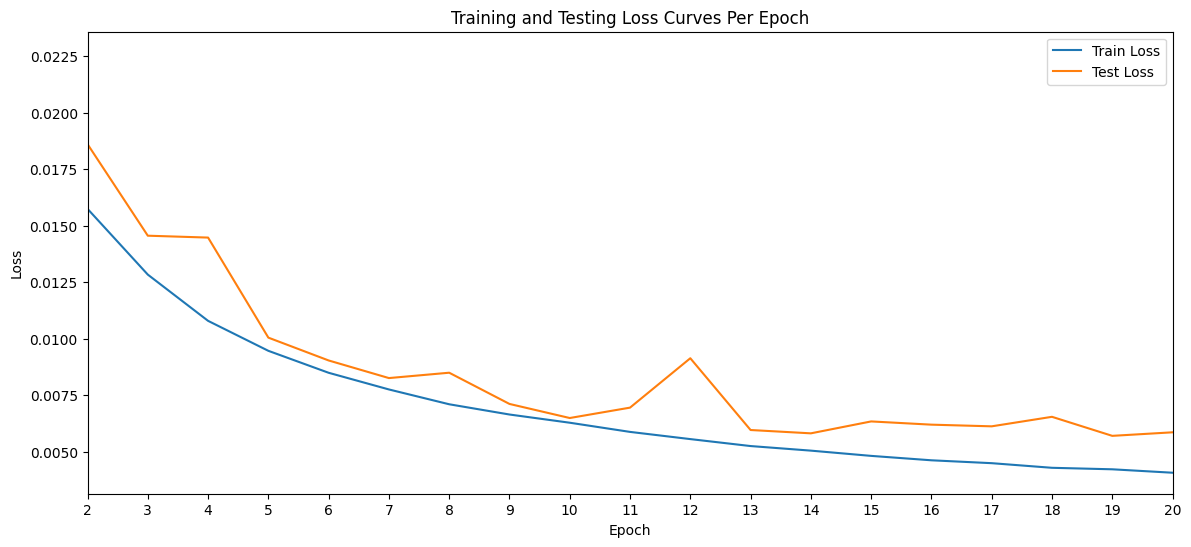

In [64]:
# Plotting Training and Testing Loss Curves
plt.figure(figsize=(14, 6))
sns.lineplot(data=train_loss_table, x="Epoch", y="Loss", label="Train Loss")
sns.lineplot(data=test_loss_table, x="Epoch", y="Loss", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Testing Loss Curves Per Epoch")
# setting x ticks to be every epoch
plt.xticks(train_accuracy_table["Epoch"])
plt.xlim(2, 20)
plt.legend()
plt.show()

### The training loss was steadily decreasing, and the test loss was also decreasing, but with some fluctuations. Both were close to each other, but the test loss started to increase at the end of training.

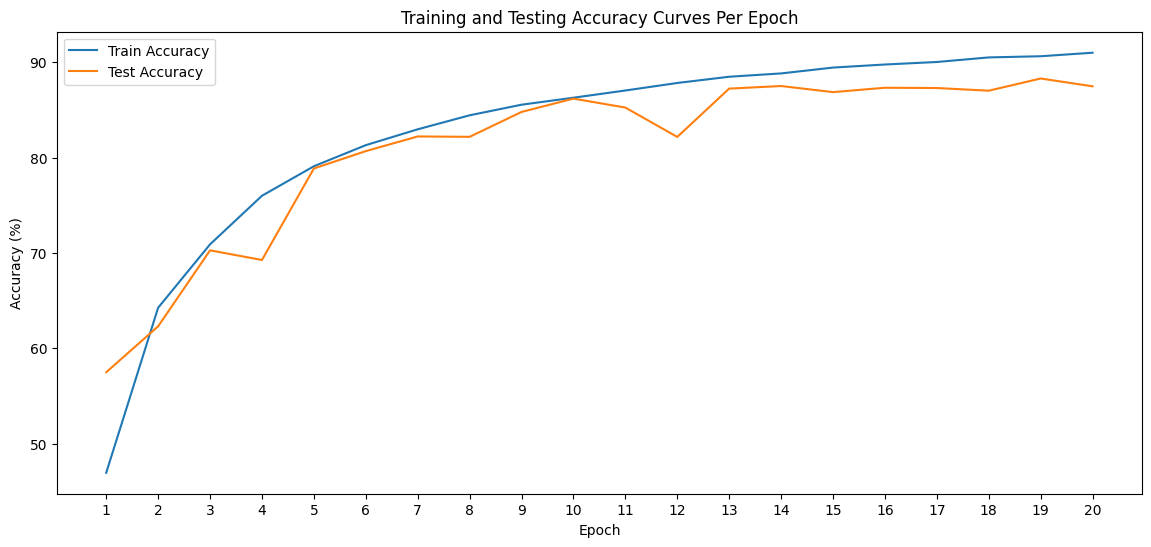

In [63]:
# Plotting Training and Testing Accuracy Curves
plt.figure(figsize=(14, 6))
sns.lineplot(data=train_accuracy_table, x="Epoch", y="Accuracy", label="Train Accuracy")
sns.lineplot(data=test_accuracy_table, x="Epoch", y="Accuracy", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Testing Accuracy Curves Per Epoch")
plt.xticks(train_accuracy_table["Epoch"])
plt.legend()
plt.show()

### The accuracy was increasing for both training and testing, but the test accuracy started to decrease at the end of training, which is a sign of overfitting. However, the training and testing accuracies remained close to each other, which is a good sign that our model is generalizing well to unseen data.

In [ ]:
# Loading the saved model
if not TRAIN_MODEL:
    PATH = "../models/cifar_resnet_scratch.pth"
    Cifar_10_ResNet = torch.load(PATH)
    Cifar_10_ResNet.to(device)

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_38928\320581313.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Cifar_10_ResNet = torch.load(PATH)


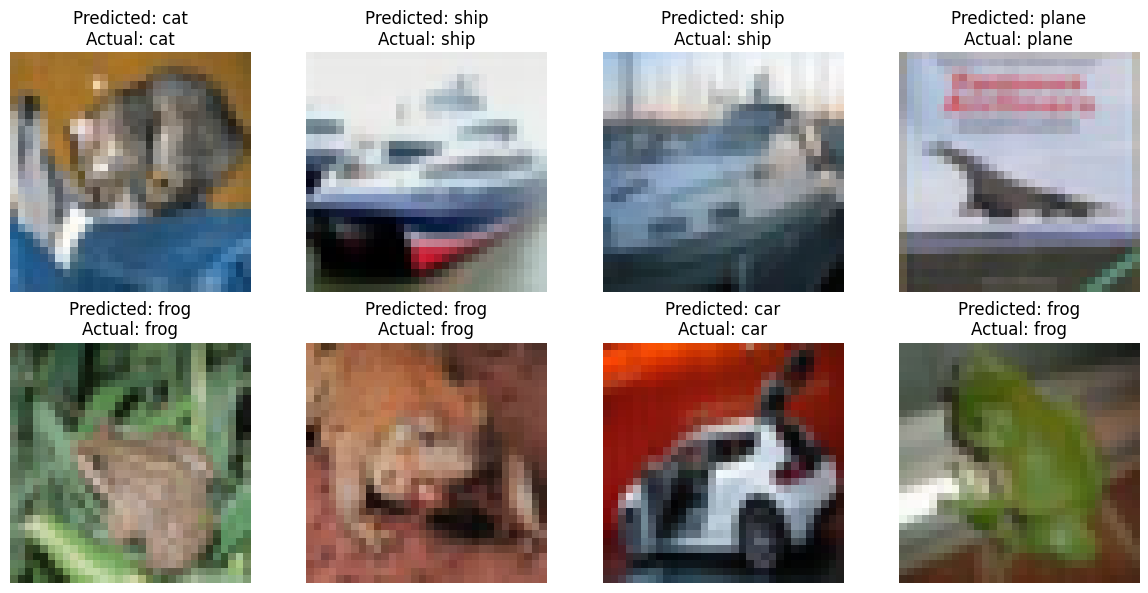

In [61]:
# Lastly we will take a small sample of the test dataset
# and see how our model performs on it, then compare it to the actual labels

# batch of test data
dataiter = iter(testloader)
images, labels = next(dataiter)

# Getting the first 8 images and labels from the batch
images = images[:8]
labels = labels[:8]

# Moving the images and labels to the same device as the model
images = images.to(device)
labels = labels.to(device)

# Getting predictions from the model
Cifar_10_ResNet.eval()
with torch.no_grad():
    outputs = Cifar_10_ResNet(images)
    _, predicted = torch.max(outputs, 1)

# Showing the images with the predicted label above the actual label
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(8):
    # we have 8 images and we want to show them in a 2x4 grid so we use i // 4 to get the row index
    # and i % 4 to get the column index
    ax = axes[i // 4, i % 4]
    # we need to unnormalize the images to show them properly because
    # we normalized them during training and testing
    img = images[i].cpu().numpy().transpose((1, 2, 0))
    # we unnormalize the image by multiplying it by the std and adding the mean then
    # we clip the values to be between 0 and 1
    img = (img * np.array([0.2023, 0.1994, 0.2010]) + np.array([0.4914, 0.4822, 0.4465])).clip(0, 1)
    ax.imshow(img)
    ax.set_title(f"Predicted: {classes[predicted[i].item()]}\nActual: {classes[labels[i].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

### This is much better than our best model from the previous notebook. The model predicted each image in the small batch of 8 images correctly.

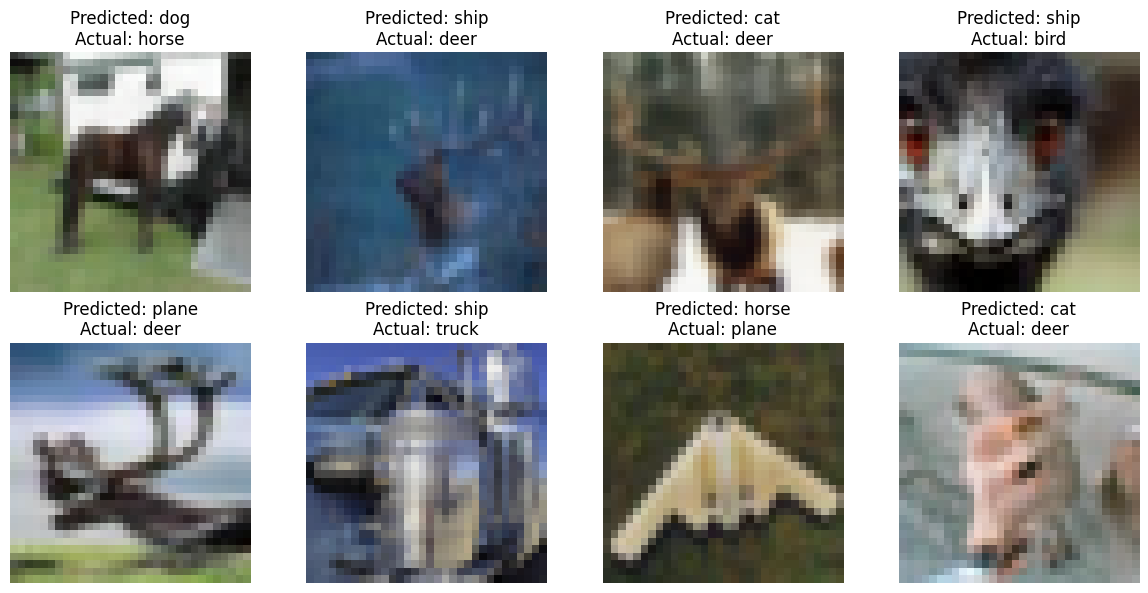

In [62]:
# Taking a small batch from the test dataset images that the model
# got wrong and showing the predicted label to see where the model is making mistakes

dataiter = iter(testloader)
images, labels = next(dataiter)


images = images.to(device)
labels = labels.to(device)


Cifar_10_ResNet.eval()
with torch.no_grad():
    outputs = Cifar_10_ResNet(images)
    _, predicted = torch.max(outputs, 1)
# Finding indices where the model's predictions are incorrect by
# comparing the predicted labels with the actual labels
incorrect_indices = (predicted != labels).nonzero(as_tuple=True)[0]
# Selecting the first 8 incorrect predictions
incorrect_indices = incorrect_indices[:8]
# Showing the images with the predicted label above the actual label
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, idx in enumerate(incorrect_indices):
    ax = axes[i // 4, i % 4]
    img = images[idx].cpu().numpy().transpose((1, 2, 0))
    img = (img * np.array([0.2023, 0.1994, 0.2010]) + np.array([0.4914, 0.4822, 0.4465])).clip(0, 1)
    ax.imshow(img)
    ax.set_title(f"Predicted: {classes[predicted[idx].item()]}\nActual: {classes[labels[idx].item()]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### The model got some obvious labels wrong. However, I have to cut it some slack because some of the images are really hard to classify even for a human. I spent a good amount of time trying to guess some of the labels myself. For example, the second image in the first row was hard to identify, but it turned out to be a deer. Also, the second image in the second row could easily be mistaken for a ship, but it is actually a truck. This is, of course, because of the low resolution of the images in the CIFAR-10 dataset. If we had higher-resolution images, it would be much easier to classify them correctly.

# In conclusion, the ResNet-18 architecture with data augmentation performed significantly better than our previous models. It achieved a much higher accuracy on the test set, and it was able to correctly classify all the images in the small batch of 8 images that we tested it on. This is a great improvement, and it shows the power of using a deeper architecture like ResNet-18.

In [ ]:
import torch

obj = torch.load("../models/cifar_pretrained_resnet_finetune.pth", map_location="cpu", weights_only=False)
print(type(obj))

FileNotFoundError: [Errno 2] No such file or directory: 'models/cifar_pretrained_resnet_finetune.pth'